In [1]:
import numpy as np
import pandas as pd
import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem
import seaborn as sns
from tqdm import tqdm
import matplotlib.pyplot as plt
from rdkit.Chem import Draw
from matplotlib.ticker import MaxNLocator
from scipy.stats import pearsonr

# Fig 4

## Panels a-f

### Generative approach

In [2]:
combinations = [
    ["BXPC3", "CAPAN2"],
    ["BXPC3", "HEK293"],
    ["CAPAN2", "HEK293"],
    ["CAPAN2", "CFPAC1"],
    ["HEK293", "BXPC3"],
    ["HEK293", "CAPAN2"],
    ["HEK293", "CFPAC1"],
]

clls = ["BXPC3", "CAPAN2", "HEK293", "CFPAC1"]

thresholds = {"CAPAN2": 30.9, "BXPC3": 21.95, "CFPAC1": 35.05, "HEK293": 48.15}

In [3]:
results = pd.read_excel(
    "../../drug screening data/Validation of generated molecules vs prediction only approach.xlsx", sheet_name = 'Validation of NCEs'
)
results.head()

,SMILES,Supplier,Supplier Ref,Conc,% Inh BXPC3 rep1,% Inh BXPC3 rep2,% Inh BXPC3 rep3,% Inh CAPAN2 rep1,% Inh CAPAN2 rep2,% Inh CAPAN2 rep3,% Inh CFPAC1 rep1,% Inh CFPAC1 rep2,% Inh CFPAC1 rep3,% Inh HEK293 rep1,% Inh HEK293 rep2,% Inh HEK293 rep3
0,C(=C1C(=O)NC2C=CC=CC=21)C1C2C=CC=CC=2NC=1C1=CC...,Maybridge,HTS05068SC,1 uM,-2.2013,4.9652,7.4744,-5.4366,-3.97960,-1.56220,0.97032,-7.1862,8.7617,21.5260,19.5270,21.0300
1,C(=C1C(=O)NC2C=CC=CC=21)C1C2C=CC=CC=2NC=1C1=CC...,Maybridge,HTS05068SC,10 uM,38.8470,26.4810,34.3020,12.9220,10.87800,-0.23526,27.18500,29.5070,20.9840,67.2060,61.1630,60.7760
2,C1(=O)C2=CC=CC=C2SC2C=CC(=CC=2N1)C(NCCC1C=CC(=...,Mcule,MCULE-1477843803,1 uM,-4.3469,-1.3673,-14.6870,-6.1786,-0.21616,-2.90370,-4.56420,-3.6454,-12.4590,6.5656,6.1441,3.9810
3,C1(=O)C2=CC=CC=C2SC2C=CC(=CC=2N1)C(NCCC1C=CC(=...,Mcule,MCULE-1477843803,10 uM,23.9910,18.6080,23.3690,9.5590,6.50400,14.46100,20.70500,9.1902,19.4930,67.5150,63.0500,61.4010
4,C1(C(=O)NC2=CC=C(C=C2)C)=C(N)C2=C(N=C3C(CCCC3)...,Mcule,MCULE-6325569038,1 uM,-11.0200,3.1101,-6.7132,-10.9430,-4.36140,-9.13320,2.20460,-3.4436,-2.4091,-7.3113,4.9472,-9.5225


In [4]:
r10uM = results[results["Conc"] == "10 uM"]

In [5]:
r1uM = results[results["Conc"] == "1 uM"]

In [6]:
# Aggregate replicates
for cll in clls:
    replicates = r10uM.filter(like=cll)
    mean2closest = []
    for i in range(len(replicates)):
        aux = replicates.iloc[i, :]
        a = abs(aux[0] - aux[1])
        b = abs(aux[0] - aux[2])
        c = abs(aux[1] - aux[2])
        min_index = np.where([a, b, c] == min([a, b, c]))[0]
        if min_index == 0:
            mean2closest.append(np.mean([aux[0], aux[1]]))
        elif min_index == 1:
            mean2closest.append(np.mean([aux[0], aux[2]]))
        elif min_index == 2:
            mean2closest.append(np.mean([aux[1], aux[2]]))

    r10uM[cll + "_mean"] = replicates.mean(axis=1)
    r10uM[cll + "_mean2closest"] = mean2closest

/tmp/ipykernel_51766/3646429094.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  a = abs(aux[0] - aux[1])
/tmp/ipykernel_51766/3646429094.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  b = abs(aux[0] - aux[2])
/tmp/ipykernel_51766/3646429094.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  c = abs(aux[1] - aux[2])
/tmp/ipykernel_51766/3646429094.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprec

In [7]:
# Aggregate replicates
for cll in clls:
    replicates = r1uM.filter(like=cll)
    mean2closest = []
    for i in range(len(replicates)):
        aux = replicates.iloc[i, :]
        a = abs(aux[0] - aux[1])
        b = abs(aux[0] - aux[2])
        c = abs(aux[1] - aux[2])
        min_index = np.where([a, b, c] == min([a, b, c]))[0]
        if min_index == 0:
            mean2closest.append(np.mean([aux[0], aux[1]]))
        elif min_index == 1:
            mean2closest.append(np.mean([aux[0], aux[2]]))
        elif min_index == 2:
            mean2closest.append(np.mean([aux[1], aux[2]]))

    r1uM[cll + "_mean"] = replicates.mean(axis=1)
    r1uM[cll + "_mean2closest"] = mean2closest

/tmp/ipykernel_51766/1274348408.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  a = abs(aux[0] - aux[1])
/tmp/ipykernel_51766/1274348408.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  b = abs(aux[0] - aux[2])
/tmp/ipykernel_51766/1274348408.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  c = abs(aux[1] - aux[2])
/tmp/ipykernel_51766/1274348408.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprec

In [8]:
# Binarize the pivot_df DataFrame based on the thresholds
r10uM_binary = r10uM.copy()  # Make a copy to avoid modifying the original DataFrame
for cll in clls:
    r10uM_binary[cll + "_mean2closest"] = r10uM_binary[cll + "_mean2closest"].apply(
        lambda x: 1 if x >= thresholds[cll] else 0
    )
r10uM_binary = r10uM_binary.filter(like="mean2closest")
r10uM_binary['Supplier Ref'] = r10uM['Supplier Ref']
r10uM_binary.head()


,BXPC3_mean2closest,CAPAN2_mean2closest,HEK293_mean2closest,CFPAC1_mean2closest,Supplier Ref
1,1,0,1,0,HTS05068SC
3,1,0,1,0,MCULE-1477843803
5,0,0,0,0,MCULE-6325569038
7,0,0,0,0,MCULE-3518770215
9,1,0,1,1,MCULE-7427575619


In [9]:
# Binarize the pivot_df DataFrame based on the thresholds
r1uM_binary = r1uM.copy()  # Make a copy to avoid modifying the original DataFrame
for cll in clls:
    r1uM_binary[cll + "_mean2closest"] = r1uM_binary[cll + "_mean2closest"].apply(
        lambda x: 1 if x >= thresholds[cll] else 0
    )
r1uM_binary = r1uM_binary.filter(like="mean2closest")
r1uM_binary['Supplier Ref'] = r1uM['Supplier Ref']
r1uM_binary.head()

,BXPC3_mean2closest,CAPAN2_mean2closest,HEK293_mean2closest,CFPAC1_mean2closest,Supplier Ref
0,0,0,0,0,HTS05068SC
2,0,0,0,0,MCULE-1477843803
4,0,0,0,0,MCULE-6325569038
6,0,0,0,0,MCULE-3518770215
8,1,0,1,0,MCULE-7427575619


In [10]:
# Binarize according to mean values

# Binarize the pivot_df DataFrame based on the thresh
for cll in clls:
    r10uM_binary[cll + "_mean"] = r10uM[cll + "_mean"].apply(
        lambda x: 1 if x >= thresholds[cll] else 0
    )

# Binarize the pivot_df DataFrame based on the threshold
for cll in clls:
    r1uM_binary[cll + "_mean"] = r1uM[cll + "_mean"].apply(
        lambda x: 1 if x >= thresholds[cll] else 0
    )

In [11]:
r1uM.head()

,SMILES,Supplier,Supplier Ref,Conc,% Inh BXPC3 rep1,% Inh BXPC3 rep2,% Inh BXPC3 rep3,% Inh CAPAN2 rep1,% Inh CAPAN2 rep2,% Inh CAPAN2 rep3,...,% Inh HEK293 rep2,% Inh HEK293 rep3,BXPC3_mean,BXPC3_mean2closest,CAPAN2_mean,CAPAN2_mean2closest,HEK293_mean,HEK293_mean2closest,CFPAC1_mean,CFPAC1_mean2closest
0,C(=C1C(=O)NC2C=CC=CC=21)C1C2C=CC=CC=2NC=1C1=CC...,Maybridge,HTS05068SC,1 uM,-2.2013,4.9652,7.4744,-5.4366,-3.97960,-1.5622,...,19.5270,21.0300,3.412767,6.21980,-3.659467,-4.70810,20.694333,21.27800,0.848607,4.86601
2,C1(=O)C2=CC=CC=C2SC2C=CC(=CC=2N1)C(NCCC1C=CC(=...,Mcule,MCULE-1477843803,1 uM,-4.3469,-1.3673,-14.6870,-6.1786,-0.21616,-2.9037,...,6.1441,3.9810,-6.800400,-2.85710,-3.099487,-1.55993,5.563567,6.35485,-6.889533,-4.10480
4,C1(C(=O)NC2=CC=C(C=C2)C)=C(N)C2=C(N=C3C(CCCC3)...,Mcule,MCULE-6325569038,1 uM,-11.0200,3.1101,-6.7132,-10.9430,-4.36140,-9.1332,...,4.9472,-9.5225,-4.874367,-8.86660,-8.145867,-10.03810,-3.962200,-8.41690,-1.216033,-2.92635
6,C1(C=CC(=CC=1O)O)C=NC1=CC=C(C=C1)N(C)C,Mcule,MCULE-3518770215,1 uM,-9.9951,-9.1056,-4.3642,8.0649,-2.63070,-7.3140,...,5.1370,3.4777,-7.821633,-9.55035,-0.626600,-4.97235,2.988263,4.30735,-11.189500,-9.59575
8,C12C(C)=CC=C(C)C=1C(C)=NC1C=C(C=CC=1S2)C(=O)NC...,Mcule,MCULE-7427575619,1 uM,39.8200,45.6820,36.0050,2.7932,-2.35720,4.6101,...,51.1790,47.8010,40.502333,37.91250,1.682033,3.70165,51.043333,52.66450,26.702333,25.83600


In [6]:
expected_results = pd.read_csv('../extra_data/expected_outcome_generated_molecules_tested.csv')
expected_results.head()

,SMILES,ID,exercises,raw_BXPC3_classifier,raw_CAPAN2_classifier,raw_CFPAC1_classifier,raw_HEK293_classifier,HEK293,BXPC3,CAPAN2,CFPAC1
0,N1C2C=C(C=CC=2SC2C=CC=CC=2C=1C)C(NCCC1C=CC=CC=...,MCULE-5830374764,['BXPC3_vs_CAPAN' 'BXPC3_vs_HEK'],0.63,0.05,NaN,0.78,0.0,1.0,0.0,NaN
1,N1C2C=C(C=CC=2SC2C=CC(Cl)=CC=2C=1CC)C(NCCCOCC)=O,MCULE-1829460973,['BXPC3_vs_HEK'],0.88,NaN,NaN,0.68,0.0,1.0,NaN,NaN
2,N1C2C=C(C=CC=2SC2C=CC(Cl)=CC=2C=1CC)C(NCCCC1C=...,MCULE-2883797677,['BXPC3_vs_HEK'],0.72,NaN,NaN,0.79,0.0,1.0,NaN,NaN
3,C12C(C)=CC=C(C)C=1C(C)=NC1C=C(C=CC=1S2)C(=O)NC...,MCULE-7427575619,['BXPC3_vs_HEK'],0.65,NaN,NaN,0.79,0.0,1.0,NaN,NaN
4,N1C2C=C(C=CC=2SC2C=CC=CC=2C=1CC)C(NCCCOC(C)C)=O,MCULE-2326121181,['BXPC3_vs_CAPAN'],0.86,0.09,NaN,NaN,NaN,1.0,0.0,NaN


In [14]:
cpds_that_work_mean_10uM_generated = {}
cpds_that_work_mean2closest_10uM_generated = {}
ngenerated = []
total_generated = []
for c in combinations:
    print(c)
    pos_cll = c[0]
    neg_cll = c[1]
    expected = (
        expected_results[["ID", pos_cll, neg_cll]]
        .sort_values(by="ID")
        .dropna()
    )
    expected = expected[np.logical_and(expected[pos_cll] == 1, expected[neg_cll] == 0)]

    gotten = r10uM_binary[r10uM_binary["Supplier Ref"].isin(expected["ID"])][
        [
            "Supplier Ref",
            pos_cll + "_mean2closest",
            neg_cll + "_mean2closest",
            pos_cll + "_mean",
            neg_cll + "_mean",
        ]
    ].sort_values(by="Supplier Ref")
    ngenerated += list(gotten['Supplier Ref'])

    total_generated.append(len(gotten))
    gotten_true_mean = gotten[
        np.logical_and(
            gotten[pos_cll + "_mean"] == 1,
            gotten[neg_cll + "_mean"] == 0,
        )
    ]

    gotten_true_mean2closest = gotten[
        np.logical_and(
            gotten[pos_cll + "_mean2closest"] == 1,
            gotten[neg_cll + "_mean2closest"] == 0,
        )
    ]

    print(len(gotten_true_mean["Supplier Ref"].values))
    print(len(gotten_true_mean2closest["Supplier Ref"].values))
    cpds_that_work_mean_10uM_generated[c[0] + "_vs_" + c[1]] = gotten_true_mean[
        "Supplier Ref"
    ].values
    cpds_that_work_mean2closest_10uM_generated[c[0] + "_vs_" + c[1]] = (
        gotten_true_mean2closest["Supplier Ref"].values
    )

['BXPC3', 'CAPAN2']
10
11
['BXPC3', 'HEK293']
1
1
['CAPAN2', 'HEK293']
0
0
['CAPAN2', 'CFPAC1']
0
0
['HEK293', 'BXPC3']
1
1
['HEK293', 'CAPAN2']
1
1
['HEK293', 'CFPAC1']
4
4


In [15]:
len(np.unique(ngenerated))

45

In [16]:
total_generated

[16, 22, 1, 1, 1, 1, 11]

In [17]:
expected_results.shape

(45, 11)

In [18]:
gotten

,Supplier Ref,HEK293_mean2closest,CFPAC1_mean2closest,HEK293_mean,CFPAC1_mean
29,MCULE-1493650762,1,0,1,0
85,MCULE-1508380250,1,0,1,0
89,MCULE-2557790400,1,0,1,0
87,MCULE-8388595355,1,0,1,0
23,S-889085173,1,1,1,1
19,S-889085174,1,1,1,1
25,S-889085175,1,1,1,1
21,S-889085176,1,1,1,1
15,Z1576602625,0,0,0,0
27,Z1883550099,0,0,0,0


In [19]:
cpds_that_work_mean_1uM_generated = {}
cpds_that_work_mean2closest_1uM_generated = {}

for c in combinations:
    print(c)
    pos_cll = c[0]
    neg_cll = c[1]
    expected = (
        expected_results[["ID", pos_cll, neg_cll]]
        .sort_values(by="ID")
        .dropna()
    )
    expected = expected[np.logical_and(expected[pos_cll] == 1, expected[neg_cll] == 0)]

    gotten = r1uM_binary[r1uM_binary["Supplier Ref"].isin(expected["ID"])][
        [
            "Supplier Ref",
            pos_cll + "_mean2closest",
            neg_cll + "_mean2closest",
            pos_cll + "_mean",
            neg_cll + "_mean",
        ]
    ].sort_values(by="Supplier Ref")

    gotten_true_mean = gotten[
        np.logical_and(
            gotten[pos_cll + "_mean"] == 1,
            gotten[neg_cll + "_mean"] == 0,
        )
    ]

    gotten_true_mean2closest = gotten[
        np.logical_and(
            gotten[pos_cll + "_mean2closest"] == 1,
            gotten[neg_cll + "_mean2closest"] == 0,
        )
    ]

    print(len(gotten_true_mean["Supplier Ref"].values))
    print(len(gotten_true_mean2closest["Supplier Ref"].values))
    cpds_that_work_mean_1uM_generated[c[0] + "_vs_" + c[1]] = gotten_true_mean[
        "Supplier Ref"
    ].values
    cpds_that_work_mean2closest_1uM_generated[c[0] + "_vs_" + c[1]] = (
        gotten_true_mean2closest["Supplier Ref"].values
    )

['BXPC3', 'CAPAN2']
3
3
['BXPC3', 'HEK293']
0
0
['CAPAN2', 'HEK293']
0
0
['CAPAN2', 'CFPAC1']
0
0
['HEK293', 'BXPC3']
0
0
['HEK293', 'CAPAN2']
0
0
['HEK293', 'CFPAC1']
1
0


In [20]:
cpds_that_work_mean2closest_10uM_generated

{'BXPC3_vs_CAPAN2': array(['MCULE-1329921853', 'MCULE-1477843803', 'MCULE-2040607482',
        'MCULE-2326121181', 'MCULE-3283587573', 'MCULE-3551346871',
        'MCULE-5074289166', 'MCULE-5830374764', 'MCULE-6814427357',
        'MCULE-8454725046', 'Z3025619666'], dtype=object),
 'BXPC3_vs_HEK293': array(['F16 [36098-33-6]'], dtype=object),
 'CAPAN2_vs_HEK293': array([], dtype=object),
 'CAPAN2_vs_CFPAC1': array([], dtype=object),
 'HEK293_vs_BXPC3': array(['MCULE-6767457754'], dtype=object),
 'HEK293_vs_CAPAN2': array(['MCULE-6767457754'], dtype=object),
 'HEK293_vs_CFPAC1': array(['MCULE-1493650762', 'MCULE-1508380250', 'MCULE-2557790400',
        'MCULE-8388595355'], dtype=object)}

In [21]:
cpds_that_work_mean_1uM_generated

{'BXPC3_vs_CAPAN2': array(['MCULE-1153524502', 'MCULE-6814427357', 'Z3025619666'],
       dtype=object),
 'BXPC3_vs_HEK293': array([], dtype=object),
 'CAPAN2_vs_HEK293': array([], dtype=object),
 'CAPAN2_vs_CFPAC1': array([], dtype=object),
 'HEK293_vs_BXPC3': array([], dtype=object),
 'HEK293_vs_CAPAN2': array([], dtype=object),
 'HEK293_vs_CFPAC1': array(['S-889085174'], dtype=object)}

In [22]:
from sklearn import metrics
from collections import Counter
from matplotlib.lines import Line2D
from scipy import stats

In [23]:
hts = pd.read_excel(
    "../../drug screening data//HTS_and_confirmation.xlsx",
    sheet_name="HTS",
)

In [24]:
p144 = pd.read_excel(
    "../../drug screening data//HTS_and_confirmation.xlsx",
    sheet_name="Control plate HEK293",
)

In [25]:
p144.columns

Index(['SMILES', 'Supplier', 'Supplier Ref', 'Conc', '%Inh HEK293 rep1',
       '%Inh HEK293 rep2', 'positives HEK293', '%Inh HEK293 mean'],
      dtype='object')

In [26]:
sum(np.isin(p144["Supplier Ref"], hts["Supplier Ref"]))

np.int64(320)

In [32]:
hts = pd.merge(hts, p144[["Supplier Ref", "%Inh HEK293 mean", "positives HEK293"]], on="Supplier Ref", how="left")
hts.shape

(11053, 25)

In [33]:
hts.head()

,SMILES,Supplier,Supplier Ref,CLNUMBER,Conc,%Inh CAPAN2,%Inh SW1990,%Inh BXPC3,%Inh HPAFII,%Inh CFPAC1,...,positives BXPC3,positives HPAFII,positives CFPAC1,positives PANC10.05,positives AsPC-1,%Inh HEK293 mean_x,positives HEK,BXPC3_vs_CAPAN2,%Inh HEK293 mean_y,positives HEK293
0,CCN(CC)C(=O)Cn1cnc2sc(C(=O)NCCCOC)c(C)c2c1=O,ChemDiv (IRB library),3909-8560,CL1572,10 uM,27.1236,10.3256,1.3229,5.8391,-1.5997,...,0,0,0,0,0,NaN,NaN,0,NaN,NaN
1,Cc1sc(-n2c(C)c3c(C)nnc(C)c3c2C)nc1-c1cccs1,ChemDiv (IRB library),6557-0199,CL2941,10 uM,6.6508,1.5008,1.1223,5.7181,14.7236,...,0,0,0,0,0,NaN,NaN,0,NaN,NaN
2,Cc1c(C(=O)O)sc2ncn(CC(=O)N3CCCCC3C)c(=O)c12,ChemDiv (IRB library),3909-9330,CL0774,10 uM,26.2876,-10.6367,-3.4028,0.9269,-12.3405,...,0,0,0,0,0,NaN,NaN,0,NaN,NaN
3,COc1ccc(-c2nc(-n3c(C)c4c(C)nnc(C)c4c3C)sc2C)cc1,ChemDiv (IRB library),6557-0202,CL2941,10 uM,7.4920,-5.6804,-4.6193,1.9559,-1.2201,...,0,0,0,0,0,NaN,NaN,0,NaN,NaN
4,Cc1cc2ncn(CC(O)COc3ccc(Cl)cc3)c2cc1C,ChemDiv (IRB library),3910-0329,CL2894,10 uM,19.8987,-0.8648,-4.7604,4.2708,3.5699,...,0,0,0,0,0,NaN,NaN,0,NaN,NaN


In [34]:
for c in combinations:
    if not np.isin("HEK293", c):
        print(c)
        pos_cll = c[0]
        neg_cll = c[1]
        hts[pos_cll + "_vs_" + neg_cll] = (
            np.logical_and(
                hts["positives " + pos_cll] == 1, hts["positives " + neg_cll] == 0
            )
            * 1
        )
    else:
        pos_cll = c[0]
        neg_cll = c[1]
        pos = []
        for i in range(len(hts)):
            if np.isnan(hts['positives HEK293'].values[i]):
                pos.append(np.nan)
            else:
                if np.logical_and(hts['positives '+pos_cll].values[i] == 1, hts['positives '+neg_cll].values[i]==0):
                    pos.append(1)
                else:
                    pos.append(0)
        hts[pos_cll + "_vs_" + neg_cll] = pos
hts.head(2)

['BXPC3', 'CAPAN2']
['CAPAN2', 'CFPAC1']


,SMILES,Supplier,Supplier Ref,CLNUMBER,Conc,%Inh CAPAN2,%Inh SW1990,%Inh BXPC3,%Inh HPAFII,%Inh CFPAC1,...,positives HEK,BXPC3_vs_CAPAN2,%Inh HEK293 mean_y,positives HEK293,BXPC3_vs_HEK293,CAPAN2_vs_HEK293,CAPAN2_vs_CFPAC1,HEK293_vs_BXPC3,HEK293_vs_CAPAN2,HEK293_vs_CFPAC1
0,CCN(CC)C(=O)Cn1cnc2sc(C(=O)NCCCOC)c(C)c2c1=O,ChemDiv (IRB library),3909-8560,CL1572,10 uM,27.1236,10.3256,1.3229,5.8391,-1.5997,...,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN
1,Cc1sc(-n2c(C)c3c(C)nnc(C)c3c2C)nc1-c1cccs1,ChemDiv (IRB library),6557-0199,CL2941,10 uM,6.6508,1.5008,1.1223,5.7181,14.7236,...,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN


In [37]:
# Data to plot
bars_generated = []
enrichements_generated = []
barstotal_generated = total_generated  ##  comes from gotten, that is the same for all the plots before when comparing to expected results
for c in combinations:
    pos_cll = c[0]
    neg_cll = c[1]
    enrichment_df = pd.DataFrame()
    hts_to_compare = hts.copy()
    hts_to_compare = hts_to_compare[['Supplier Ref', pos_cll + "_vs_" + neg_cll]].dropna()

    cpds_that_work = np.unique(
        list(cpds_that_work_mean2closest_10uM_generated[c[0] + "_vs_" + c[1]])
        + list(cpds_that_work_mean_1uM_generated[c[0] + "_vs_" + c[1]])
    )
    bars_generated.append(len(cpds_that_work))

    expected = (
        expected_results[["ID", pos_cll, neg_cll]]
        .sort_values(by="ID")
        .dropna()
    )

    expected = expected[np.logical_and(expected[pos_cll] == 1, expected[neg_cll] == 0)]

    enrichment_df["cpd"] = list(hts_to_compare["Supplier Ref"].values) + list(
        expected["ID"].values
    )
    enrichment_df["Active"] = list(hts_to_compare[pos_cll + "_vs_" + neg_cll].values) + [
        (
            1
            if np.isin(
                i,
                cpds_that_work,
            )
            else 0
        )
        for i in expected["ID"].values
    ]
    enrichment_df["Generated"] = [0] * len(hts_to_compare) + [1] * len(expected)

    confusion_matrix = metrics.confusion_matrix(
        enrichment_df["Generated"], enrichment_df["Active"].values
    )
    fisher = stats.fisher_exact(confusion_matrix)
    print(c, fisher)
    print(confusion_matrix)
    enrichements_generated.append(fisher)


pvalues = [enrichement[1] for enrichement in enrichements_generated]
odds_generated = [enrichement[0] for enrichement in enrichements_generated]
odss_new_generated = odds_generated.copy()
for i in range(len(odds_generated)):
    if odss_new_generated[i] == float("inf"):
        odss_new_generated[i] = 10000

['BXPC3', 'CAPAN2'] SignificanceResult(statistic=np.float64(273.325), pvalue=np.float64(8.689889075636727e-21))
[[10933   120]
 [    4    12]]
['BXPC3', 'HEK293'] SignificanceResult(statistic=np.float64(2.492063492063492), pvalue=np.float64(0.37481384874164264))
[[314   6]
 [ 21   1]]
['CAPAN2', 'HEK293'] SignificanceResult(statistic=np.float64(0.0), pvalue=1.0)
[[312   8]
 [  1   0]]
['CAPAN2', 'CFPAC1'] SignificanceResult(statistic=np.float64(0.0), pvalue=1.0)
[[10960    93]
 [    1     0]]
['HEK293', 'BXPC3'] SignificanceResult(statistic=inf, pvalue=np.float64(0.04672897196261682))
[[306  14]
 [  0   1]]
['HEK293', 'CAPAN2'] SignificanceResult(statistic=inf, pvalue=np.float64(0.062305295950155756))
[[301  19]
 [  0   1]]
['HEK293', 'CFPAC1'] SignificanceResult(statistic=np.float64(14.852941176470589), pvalue=np.float64(0.0002898861552524602))
[[303  17]
 [  6   5]]


In [38]:
cpds_that_work

array(['MCULE-1493650762', 'MCULE-1508380250', 'MCULE-2557790400',
       'MCULE-8388595355', 'S-889085174'], dtype='<U16')

In [ ]:
# Deltas (coming from the results in Validation of generated molecules vs prediction only approach.xlsx > DR NCEs and DR IRB lib predictions)
df_gen = pd.read_csv(
    "../extra_data/deltas_and_ratios_generated_mols_dose_response_validatio.csv"
)
df_irb = pd.read_csv(
    "../extra_data/deltas_and_ratios_irb_mols_dose_response_validatio.csv"
)

In [40]:
df_irb.head()

,Compound,Concentration,affected_cell,unaffected_cell,deltas_affected,deltas_unaffected,ratio
0,8020-7617,10uM,BXPC3,CAPAN,27.41,-7.28,2.089754
1,8020-7617,1uM,BXPC3,CAPAN,-3.80,-25.22,3.195423
2,D470-1924,10uM,BXPC3,HEK,-26.25,-42.16,0.000000
3,5591-1963,10uM,CAPAN,CFPAC,0.22,-26.06,3.461624
4,5994-0447,10uM,CAPAN,CFPAC,11.19,-23.38,3.606684


In [43]:
df_gen.head(1)

,Compound,Concentration,affected_cell,unaffected_cell,deltas_affected,deltas_unaffected,ratio
0,MCULE-1153524502,1uM,BXPC3,CAPAN,32.57,-22.46,6.459716


In [44]:
df_gen_aux = df_gen.drop(columns=["ratio"]).copy()

# Convert concentration to categorical type for proper sorting
df_gen_aux["Concentration"] = pd.Categorical(
    df_gen_aux["Concentration"], categories=["10uM", "1uM"], ordered=True
)

# Sort by concentration (descending) and reset index
df_gen_aux = df_gen_aux.sort_values("Concentration", ascending=False).reset_index(
    drop=True
)

# Drop duplicates, keeping the first occurrence (which will be the higher concentration)
df_gen_aux = df_gen_aux.drop_duplicates(
    subset=["Compound", "affected_cell", "unaffected_cell"], keep="first"
)

# Reset the index of the final DataFrame
df_gen_aux = df_gen_aux.reset_index(drop=True)
df_gen_aux = df_gen_aux.sort_values(by=["affected_cell", "unaffected_cell", "Compound"])

In [45]:
df_irb_aux = df_irb.drop(columns=["ratio"]).copy()

# Convert concentration to categorical type for proper sorting
df_irb_aux["Concentration"] = pd.Categorical(
    df_irb_aux["Concentration"], categories=["10uM", "1uM"], ordered=True
)

# Drop duplicates, keeping the first occurrence (which will be the higher concentration)
df_irb_aux = df_irb_aux.drop_duplicates(
    subset=["Compound", "affected_cell", "unaffected_cell"], keep="first"
)

# Reset the index of the final DataFrame
df_irb_aux = df_irb_aux.reset_index(drop=True)
df_irb_aux = df_irb_aux.sort_values(by=["affected_cell", "unaffected_cell", "Compound"])

/tmp/ipykernel_51766/1884014476.py:75: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax2.set_ylim(-1.0, 1500)  # Adjust these values as needed


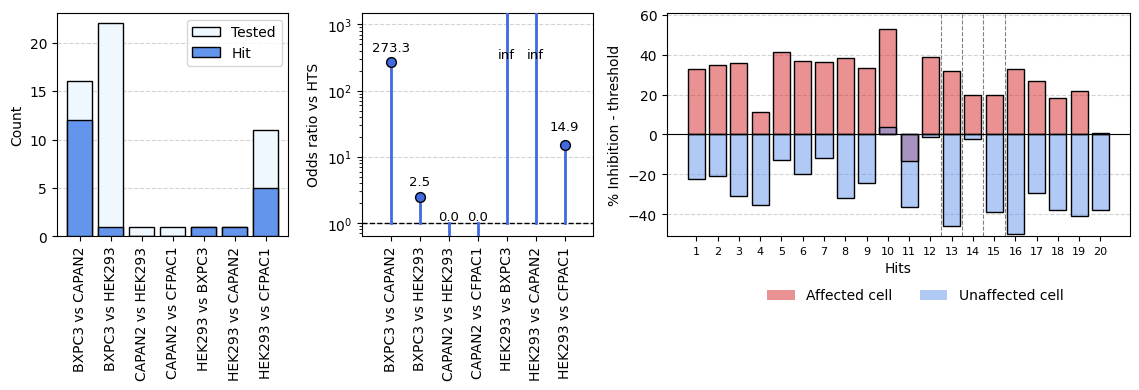

In [46]:
fig, (ax1, ax2, ax3) = plt.subplots(
    1, 3, figsize=(11.5, 4), gridspec_kw={"width_ratios": [0.25, 0.25, 0.5]}
)

## Create bar plots for generated compounds (ax1)
xlabels = [
    "BXPC3 vs CAPAN2",
    "BXPC3 vs HEK293",
    "CAPAN2 vs HEK293",
    "CAPAN2 vs CFPAC1",
    "HEK293 vs BXPC3",
    "HEK293 vs CAPAN2",
    "HEK293 vs CFPAC1",
]

ax1.bar(
    np.arange(len(bars_generated)),
    total_generated,
    color="aliceblue",
    label="Tested",
    edgecolor="black",
    zorder=3,
)
ax1.bar(
    np.arange(len(bars_generated)),
    bars_generated,
    color="cornflowerblue",
    label="Hit",
    edgecolor="black",
    zorder=4,
)

ax1.legend()
ax1.set_ylabel("Count")

## Create lollipop plot for generated compounds
colors = ["royalblue"] * len(odss_new_generated)
for i, (x, y) in enumerate(zip(np.arange(len(odss_new_generated)), odss_new_generated)):
    ax2.plot([x, x], [1, y], color=colors[i], linewidth=2, zorder=3)
    ax2.scatter(x, y, color=colors[i], s=50, zorder=4, edgecolor="black")

# Set labels for ax2
ax2.set_ylabel("Odds ratio vs HTS")

# Set logarithmic scale
ax2.set_yscale("log")

# Add horizontal line at y=1
ax2.axhline(y=1, color="black", linestyle="--", linewidth=1, zorder=2)

# Add text annotations
for i, value in enumerate(odds_generated):
    if value == 0:
        y_offset = 1
    elif value < 10:
        y_offset = 0.9
    elif value < 100:
        y_offset = 8
    else:
        y_offset = 80

    if value > 1000:
        ax2.text(i, 200 + y_offset, f"inf", ha="center", va="bottom", fontsize=9.5)
    else:
        ax2.text(
            i,
            value + y_offset,
            f"{value:.1f}",
            ha="center",
            va="bottom",
            fontsize=9.5,
        )

# Set xy-limits
ax2.set_ylim(-1.0, 1500)  # Adjust these values as needed
ax2.set_xlim(-1.0, 7)

# Set x-ticks for plots 1 and 2
for axis in [ax1, ax2]:
    axis.set_xticks(np.arange(0, len(combinations), 1), xlabels, rotation=90)


## Plot generated molecules - differences to threshold
# Color
colors_un = "cornflowerblue"
colors_af = "tab:red"
ax3.bar(
    np.arange(0, len(df_gen_aux), 1),
    df_gen_aux["deltas_affected"],
    align="center",
    alpha=0.5,
    color=colors_af,
    label="Affected cell",
    zorder=2,
)
ax3.bar(
    np.arange(0, len(df_gen_aux), 1),
    df_gen_aux["deltas_unaffected"],
    align="center",
    alpha=0.5,
    color=colors_un,
    label="Unaffected cell",
    zorder=2,
)
ax3.bar(
    np.arange(0, len(df_gen_aux), 1),
    df_gen_aux["deltas_affected"],
    align="center",
    fill=False,
    edgecolor="black",
    zorder=2,
)
ax3.bar(
    np.arange(0, len(df_gen_aux), 1),
    df_gen_aux["deltas_unaffected"],
    align="center",
    fill=False,
    edgecolor="black",
    zorder=2,
)
# ax3.legend()
# Create a separate legend
handles, labels = ax3.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.8, 0.2),
    ncol=2,
    frameon=False,
)

ax3.axvline(x=11.5, color="grey", linestyle="--", linewidth=0.8)
ax3.axvline(x=12.5, color="grey", linestyle="--", linewidth=0.8)
ax3.axvline(x=13.5, color="grey", linestyle="--", linewidth=0.8)
ax3.axvline(x=14.5, color="grey", linestyle="--", linewidth=0.8)

ax3.set_ylim(-51, 61)
# X labels for bottom plots
xlabels = []
for i in range(len(df_gen_aux)):
    c = df_gen_aux.Compound.values[i]
    if df_gen_aux.Concentration.values[i] == "1uM":
        c = c + " (1uM)"
    xlabels.append(c)

# ax3.set_xticks(ticks=np.arange(0, len(df_gen), 1), labels=xlabels, rotation=90)
ax3.axhline(y=0, color="black", linestyle="-", linewidth=0.8)
ax3.set_xlabel("Hits")
# ax3.set_xticklabels([])
# ax3.set_xticks([])
ax3.set_xticks(
    ticks=np.arange(0, len(df_gen_aux), 1),
    labels=np.arange(1, len(df_gen_aux)+1, 1),
    fontsize=8,
)

ax3.set_ylabel("% Inhibition - threshold")

for ax in [ax1, ax2, ax3]:
    ax.grid(axis="y", linestyle="--", color="lightgrey", zorder=0)
plt.tight_layout()


### Predictions only approach

In [58]:
results = pd.read_excel(
    "../../drug screening data/Validation of generated molecules vs prediction only approach.xlsx", sheet_name = 'Val. predictions on IRB lib'
)

In [63]:
r10uM = results[results["Conc"] == "10 uM"]

In [64]:
r1uM = results[results["Conc"] == "1 uM"]

In [65]:
# Aggregate replicates
for cll in clls:
    replicates = r10uM.filter(like=cll)
    mean2closest = []
    for i in range(len(replicates)):
        aux = replicates.iloc[i, :]
        a = abs(aux[0] - aux[1])
        b = abs(aux[0] - aux[2])
        c = abs(aux[1] - aux[2])
        min_index = np.where([a, b, c] == min([a, b, c]))[0]
        if min_index == 0:
            mean2closest.append(np.mean([aux[0], aux[1]]))
        elif min_index == 1:
            mean2closest.append(np.mean([aux[0], aux[2]]))
        elif min_index == 2:
            mean2closest.append(np.mean([aux[1], aux[2]]))

    r10uM[cll + "_mean"] = replicates.mean(axis=1)
    r10uM[cll + "_mean2closest"] = mean2closest

/tmp/ipykernel_51766/3646429094.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  a = abs(aux[0] - aux[1])
/tmp/ipykernel_51766/3646429094.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  b = abs(aux[0] - aux[2])
/tmp/ipykernel_51766/3646429094.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  c = abs(aux[1] - aux[2])
/tmp/ipykernel_51766/3646429094.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprec

In [66]:
# Aggregate replicates
for cll in clls:
    replicates = r1uM.filter(like=cll)
    mean2closest = []
    for i in range(len(replicates)):
        aux = replicates.iloc[i, :]
        a = abs(aux[0] - aux[1])
        b = abs(aux[0] - aux[2])
        c = abs(aux[1] - aux[2])
        min_index = np.where([a, b, c] == min([a, b, c]))[0]
        if min_index == 0:
            mean2closest.append(np.mean([aux[0], aux[1]]))
        elif min_index == 1:
            mean2closest.append(np.mean([aux[0], aux[2]]))
        elif min_index == 2:
            mean2closest.append(np.mean([aux[1], aux[2]]))

    r1uM[cll + "_mean"] = replicates.mean(axis=1)
    r1uM[cll + "_mean2closest"] = mean2closest

/tmp/ipykernel_51766/1274348408.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  a = abs(aux[0] - aux[1])
/tmp/ipykernel_51766/1274348408.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  b = abs(aux[0] - aux[2])
/tmp/ipykernel_51766/1274348408.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  c = abs(aux[1] - aux[2])
/tmp/ipykernel_51766/1274348408.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprec

In [67]:
# Binarize the pivot_df DataFrame based on the thresholds
r10uM_binary = r10uM.copy()  # Make a copy to avoid modifying the original DataFrame
for cll in clls:
    r10uM_binary[cll + "_mean2closest"] = r10uM_binary[cll + "_mean2closest"].apply(
        lambda x: 1 if x >= thresholds[cll] else 0
    )
r10uM_binary = r10uM_binary.filter(like="mean2closest")
r10uM_binary['Supplier Ref'] = r10uM['Supplier Ref']
r10uM_binary.head()


,BXPC3_mean2closest,CAPAN2_mean2closest,HEK293_mean2closest,CFPAC1_mean2closest,Supplier Ref
1,0,0,0,0,Y021-4491
3,0,0,0,0,4204-0078
5,0,0,0,0,C620-0282
7,0,1,0,0,5591-1963
9,0,0,0,0,C304-1212


In [68]:
# Binarize the pivot_df DataFrame based on the thresholds
r1uM_binary = r1uM.copy()  # Make a copy to avoid modifying the original DataFrame
for cll in clls:
    r1uM_binary[cll + "_mean2closest"] = r1uM_binary[cll + "_mean2closest"].apply(
        lambda x: 1 if x >= thresholds[cll] else 0
    )
r1uM_binary = r1uM_binary.filter(like="mean2closest")
r1uM_binary['Supplier Ref'] = r1uM['Supplier Ref']
r1uM_binary.head()

,BXPC3_mean2closest,CAPAN2_mean2closest,HEK293_mean2closest,CFPAC1_mean2closest,Supplier Ref
0,0,0,0,0,Y021-4491
2,0,0,0,0,4204-0078
4,0,0,0,0,C620-0282
6,0,0,0,0,5591-1963
8,0,0,0,0,C304-1212


In [69]:
# Binarize according to mean values

# Binarize the pivot_df DataFrame based on the thresh
for cll in clls:
    r10uM_binary[cll + "_mean"] = r10uM[cll + "_mean"].apply(
        lambda x: 1 if x >= thresholds[cll] else 0
    )

# Binarize the pivot_df DataFrame based on the threshold
for cll in clls:
    r1uM_binary[cll + "_mean"] = r1uM[cll + "_mean"].apply(
        lambda x: 1 if x >= thresholds[cll] else 0
    )

In [70]:
r1uM.head()

,SMILES,Supplier Ref,Supplier,Conc,% Inh BXPC3 rep1,% Inh BXPC3 rep2,% Inh BXPC3 rep3,% Inh CAPAN2 rep1,% Inh CAPAN2 rep2,% Inh CAPAN2 rep3,...,% Inh HEK293 rep2,% Inh HEK293 rep3,BXPC3_mean,BXPC3_mean2closest,CAPAN2_mean,CAPAN2_mean2closest,HEK293_mean,HEK293_mean2closest,CFPAC1_mean,CFPAC1_mean2closest
0,C/1\2=C(/SS\C1=N\c1ccc(S(=O)(=O)N)cc1)\C(Nc1c2...,Y021-4491,ChemDiv (IRB library),1 uM,-6.2149,0.9835,-8.5169,-8.0846,-11.36600,-8.05640,...,-6.5619,-14.343,-4.582767,-7.36590,-9.169000,-8.070500,-8.764733,-5.975600,-4.412600,-5.967600
2,CC(=O)N(C1=C(N2CCCC2)C(=O)c2ccccc2C1=O)c1ccc(C...,4204-0078,ChemDiv (IRB library),1 uM,-7.2437,2.6309,2.0599,-12.6180,-8.29010,-5.42040,...,-12.0090,-25.551,-0.850967,2.34540,-8.776167,-6.855250,-17.041333,-12.786500,0.324833,-2.940450
4,CC(C)Nc1cc(N(C)C)c2noc3c2c1C(=O)c1ccccc1-3,C620-0282,ChemDiv (IRB library),1 uM,-10.7690,-1.7485,-1.8821,-11.3310,-5.47220,-0.88255,...,-3.5330,-11.839,-4.799867,-1.81530,-5.895250,-3.177375,-5.032030,-1.628545,-0.681533,-3.773500
6,CC(C)c1ccc(S(=O)(=O)Nc2cc3sc(=O)oc3c3ccccc23)cc1,5591-1963,ChemDiv (IRB library),1 uM,-7.3825,6.8981,1.2903,3.1613,0.24273,3.03290,...,21.1080,9.675,0.268633,4.09420,2.145643,3.097100,18.617000,23.088000,-1.786303,-0.304505
8,CCC1=Nc2cc(C(=O)NC(C)c3ccccc3)ccc2Sc2ccc(C)cc21,C304-1212,ChemDiv (IRB library),1 uM,-3.8192,1.4362,-3.7517,3.1362,7.14690,3.78770,...,7.9049,-10.787,-2.044900,-3.78545,4.690267,3.461950,-1.617800,-6.379150,-0.195667,-3.401650


In [51]:
global_df = pd.DataFrame()

for pos_cll, neg_cll in combinations:
    aux = pd.read_csv(
        "../extra_data/prediction_scores_IRB_library/%s_vs_%s_IRB_high_scoring.csv"
        % (pos_cll, neg_cll)
    )
    aux = aux[["SMILES", "IDNUMBER"]]
    aux[pos_cll] = 1
    aux[neg_cll] = 0
    global_df = pd.concat([global_df, aux], ignore_index=True)

In [52]:
global_df.head()

,SMILES,IDNUMBER,BXPC3,CAPAN2,HEK293,CFPAC1
0,COc1ccc(C2C(C#N)=C(N)N(c3ccccc3)C3=C2C(=O)CCC3...,8007-1019,1.0,0.0,NaN,NaN
1,CCC1=Nc2cc(C(=O)NC(C)c3ccccc3)ccc2Sc2ccc(C)cc21,C304-1212,1.0,0.0,NaN,NaN
2,COc1ccc2c(Nc3cccc(SC)c3)c(C#N)cnc2c1,F360-0681,1.0,0.0,NaN,NaN
3,O=S(=O)(c1ccc(-c2nnc(C3CCC3)o2)s1)N1CCCc2ccccc21,F630-0873,1.0,0.0,NaN,NaN
4,NC(N(C(CCC1)=C(C2c(cc3)ccc3F)C1=O)c(cc1)ccc1F)...,8007-2931,1.0,0.0,NaN,NaN


In [53]:
global_df.shape

(67, 6)

In [54]:
global_df_unique = global_df.groupby("IDNUMBER", as_index=False).max()

In [55]:
global_df_unique.head(2)

,IDNUMBER,SMILES,BXPC3,CAPAN2,HEK293,CFPAC1
0,0234-0037,Nc1c(C(=O)O)cc(Br)c2c1C(=O)c1ccccc1C2=O,NaN,1.0,0.0,NaN
1,0310-0156,O=C(c(cccc1)c1-c1c2c(cc3)no1)c2c3NCCCl,NaN,1.0,0.0,NaN


In [56]:
global_df_unique.shape

(58, 6)

In [59]:
results.head(2)

,SMILES,Supplier Ref,Supplier,Conc,% Inh BXPC3 rep1,% Inh BXPC3 rep2,% Inh BXPC3 rep3,% Inh CAPAN2 rep1,% Inh CAPAN2 rep2,% Inh CAPAN2 rep3,% Inh CFPAC1 rep1,% Inh CFPAC1 rep2,% Inh CFPAC1 rep3,% Inh HEK293 rep1,% Inh HEK293 rep2,% Inh HEK293 rep3
0,C/1\2=C(/SS\C1=N\c1ccc(S(=O)(=O)N)cc1)\C(Nc1c2...,Y021-4491,ChemDiv (IRB library),1 uM,-6.2149,0.9835,-8.5169,-8.0846,-11.366,-8.0564,-5.0542,-1.30260,-6.8810,-5.3893,-6.5619,-14.3430
1,C/1\2=C(/SS\C1=N\c1ccc(S(=O)(=O)N)cc1)\C(Nc1c2...,Y021-4491,ChemDiv (IRB library),10 uM,-1.8667,7.2711,1.8532,3.0307,11.965,1.8389,3.3136,-0.88575,-1.9479,15.8640,13.5470,5.0877


In [72]:
enrichements_irb = []
for c in combinations:
    pos_cll = c[0]
    neg_cll = c[1]
    enrichment_df = pd.DataFrame()
    hts_to_compare = hts.copy()
    hts_to_compare = hts_to_compare[['Supplier Ref', pos_cll + "_vs_" + neg_cll]].dropna()

    expected = (
        global_df_unique[["IDNUMBER", pos_cll, neg_cll]]
        .sort_values(by="IDNUMBER")
        .dropna()
    )
    expected = expected[np.logical_and(expected[pos_cll] == 1, expected[neg_cll] == 0)]
    if True:
        enrichment_df["cpd"] = list(hts_to_compare["Supplier Ref"].values) + list(
            expected["IDNUMBER"].values
        )
        enrichment_df["Active"] = list(hts_to_compare[pos_cll + "_vs_" + neg_cll].values) + [
            (
                1
                if np.isin(
                    i,
                    r10uM_binary['Supplier Ref'].values[
                        np.logical_and(
                            r10uM_binary[pos_cll + "_mean2closest"] == 1,
                            r10uM_binary[neg_cll + "_mean2closest"] == 0,
                        )
                    ],
                )
                else 0
            )
            for i in expected["IDNUMBER"].values
        ]

        enrichment_df["Generated"] = [0] * len(hts_to_compare) + [1] * len(expected)

    else:
        enrichment_df["cpd"] = list(confirmation["Supplier Ref"].values) + list(
            expected["IDNUMBER"].values
        )
        enrichment_df["Active"] = list(
            confirmation[pos_cll + "_vs_" + neg_cll].values
        ) + [
            (
                1
                if np.isin(
                    i,
                    r10uM_binary.cpd[
                        np.logical_and(
                            r10uM_binary[pos_cll + "_mean2closest"] == 1,
                            r10uM_binary[neg_cll + "_mean2closest"] == 0,
                        )
                    ],
                )
                else 0
            )
            for i in expected["IDNUMBER"].values
        ]

        enrichment_df["Generated"] = [0] * len(confirmation) + [1] * len(expected)

    confusion_matrix = metrics.confusion_matrix(
        enrichment_df["Generated"], enrichment_df["Active"].values
    )
    fisher = stats.fisher_exact(confusion_matrix)
    print(c, fisher)
    print(confusion_matrix)
    enrichements_irb.append(fisher)

['BXPC3', 'CAPAN2'] SignificanceResult(statistic=np.float64(15.184722222222222), pvalue=np.float64(0.07413355955414007))
[[10933   120]
 [    6     1]]
['BXPC3', 'HEK293'] SignificanceResult(statistic=np.float64(13.083333333333334), pvalue=np.float64(0.10376506401883082))
[[314   6]
 [  4   1]]
['CAPAN2', 'HEK293'] SignificanceResult(statistic=np.float64(6.24), pvalue=np.float64(0.012006597554786936))
[[312   8]
 [ 25   4]]
['CAPAN2', 'CFPAC1'] SignificanceResult(statistic=np.float64(36.261373035566585), pvalue=np.float64(1.2080291495405173e-05))
[[10960    93]
 [   13     4]]
['HEK293', 'BXPC3'] SignificanceResult(statistic=np.float64(10.928571428571429), pvalue=np.float64(0.13334331358668913))
[[306  14]
 [  2   1]]
['HEK293', 'CAPAN2'] SignificanceResult(statistic=np.float64(15.842105263157896), pvalue=np.float64(0.12054720303399699))
[[301  19]
 [  1   1]]
['HEK293', 'CFPAC1'] SignificanceResult(statistic=np.float64(0.0), pvalue=1.0)
[[303  17]
 [  4   0]]


In [75]:
pos_clls, neg_clls, true, true1um, total_irb = [], [], [], [], []
nirb_tested = []
cpds_that_work_10um_irb = {}
cpds_that_work_1um_irb = {}
for c in combinations:
    print(c)
    pos_cll = c[0]
    neg_cll = c[1]
    pos_clls.append(pos_cll)
    neg_clls.append(neg_cll)
    expected = (
        global_df_unique[["IDNUMBER", pos_cll, neg_cll]]
        .sort_values(by="IDNUMBER")
        .dropna()
    )
    expected = expected[np.logical_and(expected[pos_cll] == 1, expected[neg_cll] == 0)]

    gotten = r10uM_binary[r10uM_binary["Supplier Ref"].isin(expected["IDNUMBER"])][
        ["Supplier Ref", pos_cll + "_mean2closest", neg_cll + "_mean2closest"]
    ].sort_values(by="Supplier Ref")
    nirb_tested += list(gotten['Supplier Ref'].values)

    gotten_1um = r1uM_binary[r1uM_binary["Supplier Ref"].isin(expected["IDNUMBER"])][
        ["Supplier Ref", pos_cll + "_mean2closest", neg_cll + "_mean2closest"]
    ].sort_values(by="Supplier Ref")
    nirb_tested += list(gotten['Supplier Ref'].values)

    gotten_1um = r1uM_binary[r1uM_binary["Supplier Ref"].isin(expected["IDNUMBER"])][
        ["Supplier Ref", pos_cll + "_mean2closest", neg_cll + "_mean2closest"]
    ].sort_values(by="Supplier Ref")
    nirb_tested += list(gotten['Supplier Ref'].values)

    gotten_1um = r1uM_binary[r1uM_binary["Supplier Ref"].isin(expected["IDNUMBER"])][
        ["Supplier Ref", pos_cll + "_mean2closest", neg_cll + "_mean2closest"]
    ].sort_values(by="Supplier Ref")

    gotten_true = gotten[
        np.logical_and(
            gotten[pos_cll + "_mean2closest"] == 1,
            gotten[neg_cll + "_mean2closest"] == 0,
        )
    ]

    gotten_true_1um = gotten_1um[
        np.logical_and(
            gotten_1um[pos_cll + "_mean2closest"] == 1,
            gotten_1um[neg_cll + "_mean2closest"] == 0,
        )
    ]

    cpds_that_work_10um_irb[pos_cll + "_vs_" + neg_cll] = gotten_true["Supplier Ref"].values
    cpds_that_work_1um_irb[pos_cll + "_vs_" + neg_cll] = gotten_true_1um["Supplier Ref"].values

    print("True 10uM:", gotten_true.shape[0])
    print("True 1uM:", gotten_true_1um.shape[0])
    print("Total:", gotten.shape[0])
    true.append(gotten_true.shape[0])
    true1um.append(gotten_true_1um.shape[0])
    total_irb.append(gotten.shape[0])

['BXPC3', 'CAPAN2']
True 10uM: 1
True 1uM: 1
Total: 7
['BXPC3', 'HEK293']
True 10uM: 1
True 1uM: 0
Total: 5
['CAPAN2', 'HEK293']
True 10uM: 4
True 1uM: 0
Total: 27
['CAPAN2', 'CFPAC1']
True 10uM: 4
True 1uM: 0
Total: 17
['HEK293', 'BXPC3']
True 10uM: 1
True 1uM: 0
Total: 3
['HEK293', 'CAPAN2']
True 10uM: 1
True 1uM: 0
Total: 2
['HEK293', 'CFPAC1']
True 10uM: 0
True 1uM: 0
Total: 4


In [76]:
total_irb

[7, 5, 27, 17, 3, 2, 4]

In [77]:
len(np.unique(nirb_tested))

56

In [78]:
# Data to plot
bars10um_irb = []
bars1um_irb = []
barstotal_irb = total_irb  ##  comes from gotten, that is the same for all the plots before when comparing to expected results
for c in combinations:
    pos_cll = c[0]
    neg_cll = c[1]
    bars10um_irb.append(len(cpds_that_work_10um_irb[c[0] + "_vs_" + c[1]]))
    bars1um_irb.append(len(cpds_that_work_1um_irb[c[0] + "_vs_" + c[1]]))

pvalues = [enrichement[1] for enrichement in enrichements_irb]
odds_irb = [enrichement[0] for enrichement in enrichements_irb]
odss_new_irb = odds_irb.copy()
for i in range(len(odds_irb)):
    if odss_new_irb[i] == float("inf"):
        odss_new_irb[i] = 650

/tmp/ipykernel_51766/404267199.py:75: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax2.set_ylim(-1.0, 1500)  # Adjust these values as needed


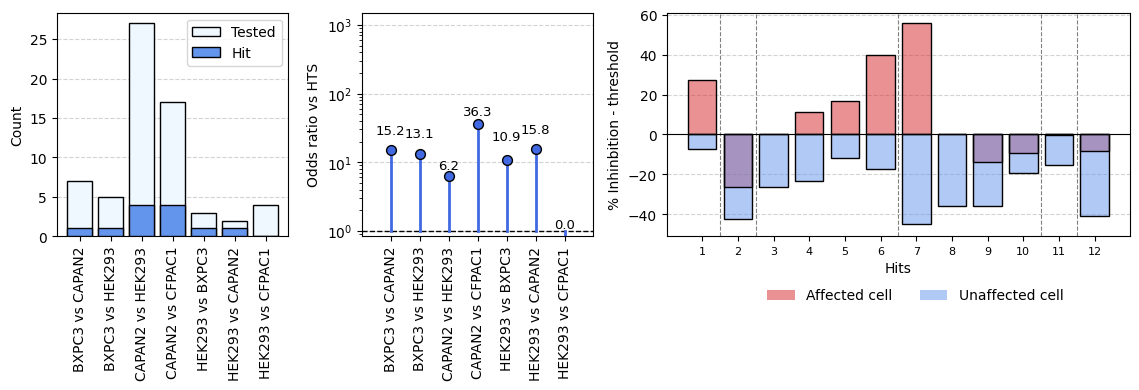

In [79]:
fig, (ax1, ax2, ax3) = plt.subplots(
    1, 3, figsize=(11.5, 4), gridspec_kw={"width_ratios": [0.25, 0.25, 0.5]}
)

## Create bar plots for generated compounds (ax1)
xlabels = [
    "BXPC3 vs CAPAN2",
    "BXPC3 vs HEK293",
    "CAPAN2 vs HEK293",
    "CAPAN2 vs CFPAC1",
    "HEK293 vs BXPC3",
    "HEK293 vs CAPAN2",
    "HEK293 vs CFPAC1",
]

ax1.bar(
    np.arange(len(total_irb)),
    total_irb,
    color="aliceblue",
    label="Tested",
    edgecolor="black",
    zorder=3,
)
ax1.bar(
    np.arange(len(bars10um_irb)),
    bars10um_irb,
    color="cornflowerblue",
    label="Hit",
    edgecolor="black",
    zorder=4,
)

ax1.legend()
ax1.set_ylabel("Count")

## Create lollipop plot for generated compounds
colors = ["royalblue"] * len(odss_new_irb)
for i, (x, y) in enumerate(zip(np.arange(len(odss_new_irb)), odss_new_irb)):
    ax2.plot([x, x], [1, y], color=colors[i], linewidth=2, zorder=3)
    ax2.scatter(x, y, color=colors[i], s=50, zorder=4, edgecolor="black")

# Set labels for ax2
ax2.set_ylabel("Odds ratio vs HTS")

# Set logarithmic scale
ax2.set_yscale("log")

# Add horizontal line at y=1
ax2.axhline(y=1, color="black", linestyle="--", linewidth=1, zorder=2)

# Add text annotations
for i, value in enumerate(odds_irb):
    if value == 0:
        y_offset = 1
    elif value < 10:
        y_offset = 0.9
    elif value < 100:
        y_offset = 8
    else:
        y_offset = 80

    if value > 1000:
        ax2.text(i, 200 + y_offset, f"inf", ha="center", va="bottom", fontsize=9.5)
    else:
        ax2.text(
            i,
            value + y_offset,
            f"{value:.1f}",
            ha="center",
            va="bottom",
            fontsize=9.5,
        )

# Set xy-limits
ax2.set_ylim(-1.0, 1500)  # Adjust these values as needed
ax2.set_xlim(-1.0, 7)

# Set x-ticks for plots 1 and 2
for axis in [ax1, ax2]:
    axis.set_xticks(np.arange(0, len(combinations), 1), xlabels, rotation=90)


## Plot generated molecules - differences to threshold
# Color
colors_un = "cornflowerblue"
colors_af = "tab:red"

ax3.bar(
    np.arange(0, len(df_irb_aux), 1),
    df_irb_aux["deltas_affected"],
    align="center",
    alpha=0.5,
    color=colors_af,
    label="Affected cell",
    zorder=2,
)
ax3.bar(
    np.arange(0, len(df_irb_aux), 1),
    df_irb_aux["deltas_unaffected"],
    align="center",
    alpha=0.5,
    color=colors_un,
    label="Unaffected cell",
    zorder=2,
)
ax3.bar(
    np.arange(0, len(df_irb_aux), 1),
    df_irb_aux["deltas_affected"],
    align="center",
    fill=False,
    edgecolor="black",
    zorder=2,
)
ax3.bar(
    np.arange(0, len(df_irb_aux), 1),
    df_irb_aux["deltas_unaffected"],
    align="center",
    fill=False,
    edgecolor="black",
    zorder=2,
)
# ax3.legend()
# Create a separate legend
handles, labels = ax3.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.8, 0.2),
    ncol=2,
    frameon=False,
)

ax3.axvline(x=0.5, color="grey", linestyle="--", linewidth=0.8)
ax3.axvline(x=1.5, color="grey", linestyle="--", linewidth=0.8)
ax3.axvline(x=5.5, color="grey", linestyle="--", linewidth=0.8)
ax3.axvline(x=9.5, color="grey", linestyle="--", linewidth=0.8)
ax3.axvline(x=10.5, color="grey", linestyle="--", linewidth=0.8)

ax3.set_ylim(-51, 61)
# X labels for last plot
ax3.set_xlabel("Hits")
# ax3.set_xticklabels([])
# ax3.set_xticks([])
ax3.set_xticks(
    ticks=np.arange(0, len(df_irb_aux), 1),
    labels=np.arange(1, len(df_irb_aux)+1, 1),
    fontsize=8,
)

ax3.axhline(y=0, color="black", linestyle="-", linewidth=0.8)

ax3.set_ylabel("% Inhinbition - threshold")

for ax in [ax1, ax2, ax3]:
    ax.grid(axis="y", linestyle="--", color="lightgrey", zorder=0)
plt.tight_layout()

## Panes g-i

In [3]:
expected_results = pd.read_csv('../extra_data/expected_outcome_generated_molecules_tested.csv')

In [4]:
cpd2inchi = dict(zip(expected_results['ID'], expected_results['inchi']))

In [5]:
cpds_that_worked = {
    "BXPC3_vs_CAPAN2": [
        "Z3025619666",
        "MCULE-1153524502",
        "MCULE-2326121181",
        "MCULE-5074289166",
        "MCULE-5830374764",
        "MCULE-3283587573",
        "MCULE-1477843803",
        "MCULE-2040607482",
        "MCULE-3551346871",
        "MCULE-1329921853",
     ],
    # 'MCULE-1153524502', 'MCULE-1329921853', 'MCULE-1477843803',
    #     'MCULE-2040607482', 'MCULE-2326121181', 'MCULE-3283587573',
    #     'MCULE-3551346871', 'MCULE-5074289166', 'MCULE-5830374764',
    #     'MCULE-6814427357', 'MCULE-8454725046', 'Z3025619666'],
    "BXPC3_vs_HEK293": ["F16 [36098-33-6]"],
    "HEK293_vs_BXPC3": ["MCULE-6767457754"],
    "HEK293_vs_CAPAN2": ["MCULE-6767457754"],
    "HEK293_vs_CFPAC1": [
        "MCULE-8388595355",
        'S-889085176',
        "MCULE-1508380250",
        "MCULE-2557790400",
        "MCULE-1493650762",
    ],
}

In [6]:
def smiles_to_fingerprint(smiles_list):
    """
    Convert a list of SMILES strings to molecular fingerprints.
    """
    fingerprints = []
    for smiles in smiles_list:
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            fingerprint = AllChem.GetMorganFingerprintAsBitVect(
                mol, 2, nBits=2048
            )  # Morgan fingerprint with radius 2
            fingerprints.append(fingerprint)
        else:
            print(f"Invalid SMILES string: {smiles}")
    return fingerprints


def compute_tanimoto_similarity(fingerprint1, fingerprint2):
    """
    Compute the Tanimoto similarity between two fingerprints.
    """
    return AllChem.DataStructs.TanimotoSimilarity(fingerprint1, fingerprint2)

In [7]:
from rdkit import Chem
from rdkit.Chem import AllChem

global_results = pd.DataFrame()
for c in combinations:
    pos_cll = c[0]
    neg_cll = c[1]
    if pos_cll == "CAPAN2": # becasue no compound worked for these exercises
        continue
    cpds = cpds_that_worked[pos_cll + "_vs_" + neg_cll]
    print(cpds)
    generated_cpds_vs_to_buy = pd.read_csv(
        "../extra_data/generated_molecules/high_scoring_cpds_found_in_dbs_%s_vs_%s.csv"
        % (pos_cll, neg_cll)
    )

    inchis_worked = [cpd2inchi[s] for s in cpds]

    tanimotos_worked = []
    tanimotos_manual_worked = []
    max_tanimotos_worked = []
    for n, s in enumerate(inchis_worked):
        tanimotos_worked.append(
            max(
                generated_cpds_vs_to_buy["tanimoto_gen_vs_to_buy"].values[
                    generated_cpds_vs_to_buy["inchi_to_buy"] == s
                ]
            )
        )

        # Compute tanimotos manually
        mol1 = Chem.MolFromInchi(s)
        fp1 = AllChem.GetMorganFingerprintAsBitVect(
            mol1, 2, nBits=1024
        )  # Morgan fingerprint with radius 2
        qry_inchis = generated_cpds_vs_to_buy["qryInchis"].values[
            generated_cpds_vs_to_buy["inchi_to_buy"] == s
        ]
        qry_mols = [Chem.MolFromInchi(a) for a in qry_inchis]
        qry_fps = [
            AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=1024)
            for mol in qry_mols
        ]

        qry_tanimotos = [compute_tanimoto_similarity(fp1, fp) for fp in qry_fps]
        tanimotos_manual_worked.append(max(qry_tanimotos))

        max_tanimotos_worked.append(
            max(tanimotos_manual_worked[-1], tanimotos_worked[-1])
        )

    tanimotos_noworked = []
    tanimotos_manual_noworked = []
    max_tanimotos_noworked = []

    # Get inchis that didn't work
    expected = (
        expected_results[["ID", pos_cll, neg_cll]]
        .sort_values(by="ID")
        .dropna()
    )
    expected = expected[np.logical_and(expected[pos_cll] == 1, expected[neg_cll] == 0)]
    cpds_noworked = expected["ID"][~expected["ID"].isin(cpds)]
    inchis_noworked = [cpd2inchi[s] for s in cpds_noworked]

    for n, s in enumerate(inchis_noworked):
        tanimotos_noworked.append(
            max(
                generated_cpds_vs_to_buy["tanimoto_gen_vs_to_buy"].values[
                    generated_cpds_vs_to_buy["inchi_to_buy"] == s
                ]
            )
        )

        # Compute tanimotos manually
        mol1 = Chem.MolFromInchi(s)
        fp1 = AllChem.GetMorganFingerprintAsBitVect(
            mol1, 2, nBits=1024
        )  # Morgan fingerprint with radius 2
        qry_inchis = generated_cpds_vs_to_buy["qryInchis"].values[
            generated_cpds_vs_to_buy["inchi_to_buy"] == s
        ]
        qry_mols = [Chem.MolFromInchi(a) for a in qry_inchis]
        qry_fps = [
            AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=1024)
            for mol in qry_mols
        ]

        qry_tanimotos = [compute_tanimoto_similarity(fp1, fp) for fp in qry_fps]
        tanimotos_manual_noworked.append(max(qry_tanimotos))

        max_tanimotos_noworked.append(
            max(tanimotos_manual_noworked[-1], tanimotos_noworked[-1])
        )

    data = pd.DataFrame()
    data["cpd"] = list(cpds) + list(cpds_noworked)
    data["Hit"] = [1] * len(cpds) + [0] * len(cpds_noworked)
    data["tanimotos"] = max_tanimotos_worked + max_tanimotos_noworked
    data["exercise"] = [c[0] + "_vs_" + c[1]] * len(data)

    global_results = pd.concat([global_results, data], ignore_index=True)

['Z3025619666', 'MCULE-1153524502', 'MCULE-2326121181', 'MCULE-5074289166', 'MCULE-5830374764', 'MCULE-3283587573', 'MCULE-1477843803', 'MCULE-2040607482', 'MCULE-3551346871', 'MCULE-1329921853']
['F16 [36098-33-6]']


[10:21:01] DEPRECATION WARNING: please use MorganGenerator
[10:21:01] DEPRECATION WARNING: please use MorganGenerator
[10:21:01] DEPRECATION WARNING: please use MorganGenerator
[10:21:01] DEPRECATION WARNING: please use MorganGenerator
[10:21:01] DEPRECATION WARNING: please use MorganGenerator
[10:21:01] DEPRECATION WARNING: please use MorganGenerator
[10:21:01] DEPRECATION WARNING: please use MorganGenerator
[10:21:01] DEPRECATION WARNING: please use MorganGenerator
[10:21:01] DEPRECATION WARNING: please use MorganGenerator
[10:21:01] DEPRECATION WARNING: please use MorganGenerator
[10:21:01] DEPRECATION WARNING: please use MorganGenerator
[10:21:01] DEPRECATION WARNING: please use MorganGenerator
[10:21:01] DEPRECATION WARNING: please use MorganGenerator
[10:21:01] DEPRECATION WARNING: please use MorganGenerator
[10:21:01] DEPRECATION WARNING: please use MorganGenerator
[10:21:01] DEPRECATION WARNING: please use MorganGenerator
[10:21:01] DEPRECATION WARNING: please use MorganGenerat

['MCULE-6767457754']
['MCULE-6767457754']
['MCULE-8388595355', 'S-889085176', 'MCULE-1508380250', 'MCULE-2557790400', 'MCULE-1493650762']


[10:21:01] DEPRECATION WARNING: please use MorganGenerator
[10:21:01] DEPRECATION WARNING: please use MorganGenerator
[10:21:01] DEPRECATION WARNING: please use MorganGenerator
[10:21:01] DEPRECATION WARNING: please use MorganGenerator
[10:21:01] DEPRECATION WARNING: please use MorganGenerator
[10:21:01] DEPRECATION WARNING: please use MorganGenerator
[10:21:01] DEPRECATION WARNING: please use MorganGenerator
[10:21:01] DEPRECATION WARNING: please use MorganGenerator
[10:21:01] DEPRECATION WARNING: please use MorganGenerator
[10:21:01] DEPRECATION WARNING: please use MorganGenerator
[10:21:01] DEPRECATION WARNING: please use MorganGenerator
[10:21:01] DEPRECATION WARNING: please use MorganGenerator
[10:21:01] DEPRECATION WARNING: please use MorganGenerator
[10:21:01] DEPRECATION WARNING: please use MorganGenerator
[10:21:01] DEPRECATION WARNING: please use MorganGenerator
[10:21:01] DEPRECATION WARNING: please use MorganGenerator
[10:21:01] DEPRECATION WARNING: please use MorganGenerat

In [8]:
training = pd.read_excel(
    "../../drug screening data/HTS_and_confirmation.xlsx", sheet_name = 'Training set'
)
training.head()

,SMILES,Supplier,Supplier Ref,CLNUMBER,Conc,%Inh CAPAN2,%Inh SW1990,%Inh BXPC3,%Inh HPAFII,%Inh CFPAC1,...,%Inh HEK293,positives CAPAN2,positives SW1990,positives BXPC3,positives HPAFII,positives CFPAC1,positives PANC10.05,positives AsPC-1,positives U2OS,positives HEK293
0,Cc1ccc2nc3c(c(Nc4ccccc4)c2c1)CCC3,ChemDiv (IRB library),3931-1998,CL3010,10 uM,34.59445,19.46375,10.36140,22.38685,22.96545,...,49.12555,1,0,0,1,0,0,0,0,1
1,O=C1c2ccccc2C(=O)c2c1cccc2N1CCC(O)CC1,ChemDiv (IRB library),6612-0273,CL0699,10 uM,71.84750,7.63780,8.73805,15.20475,6.18435,...,-3.11180,1,0,0,0,0,0,0,0,0
2,Cc1ccc2c(c1)c1c(n2CC(O)CNCc2ccccc2)CCCC1,ChemDiv (IRB library),6658-0003,CL1206,10 uM,37.81100,36.61605,6.38895,14.75835,19.22960,...,32.66685,1,0,0,0,0,1,0,0,0
3,c1ccc(-c2nc3c4c5c(sc4ncn3n2)CCCCC5)cc1,ChemDiv (IRB library),4072-2778,CL1989,10 uM,2.58995,-3.88405,-1.65090,-2.66615,-1.20870,...,-8.68985,0,0,0,0,0,0,0,0,0
4,CC(C)c1ccc(C2C3=C(CC(C)(C)CC3=O)Nc3nn(-c4ccccc...,ChemDiv (IRB library),6359-0280,CL4744,10 uM,4.33115,0.20310,-0.66100,-0.76515,3.78565,...,3.58205,0,0,0,0,0,0,0,0,0


In [9]:
training.columns

Index(['SMILES', 'Supplier', 'Supplier Ref', 'CLNUMBER', 'Conc', '%Inh CAPAN2',
       '%Inh SW1990', '%Inh BXPC3', '%Inh HPAFII', '%Inh CFPAC1',
       '%Inh PANC10.05', '%Inh AsPC-1', '%Inh U2OS', '%Inh HEK293',
       'positives CAPAN2', 'positives SW1990', 'positives BXPC3',
       'positives HPAFII', 'positives CFPAC1', 'positives PANC10.05',
       'positives AsPC-1', 'positives U2OS', 'positives HEK293'],
      dtype='object')

In [10]:
cpd2smiles = dict(zip(expected_results["ID"], expected_results["SMILES"]))

In [11]:
from rdkit.Chem import AllChem

max_sim = []
for c in combinations:
    pos_cll = c[0]
    neg_cll = c[1]
    actives_in_training = training[
        np.logical_and(
            training["positives %s" % pos_cll] == 1,
            training["positives %s" % neg_cll] == 0,
        )
    ]["SMILES"].values
    print("# actives in training:", len(actives_in_training))

    try:
        cpds = [cpd2smiles[s] for s in cpds_that_worked[pos_cll + "_vs_" + neg_cll]]
    except:
        continue

    if len(cpds) > 0 and len(actives_in_training) > 0:
        # Convert SMILES strings to fingerprints
        fingerprints1 = smiles_to_fingerprint(cpds)
        fingerprints2 = smiles_to_fingerprint(actives_in_training)

        similarities = []

        for i, fingerprint1 in enumerate(fingerprints1):
            max_similarity = 0
            for fingerprint2 in fingerprints2:
                similarity = compute_tanimoto_similarity(fingerprint1, fingerprint2)
                similarities.append(similarity)
                max_similarity = max(max_similarity, similarity)
            max_sim.append(max_similarity)

# actives in training: 84
# actives in training: 54
# actives in training: 82
# actives in training: 84
# actives in training: 78
# actives in training: 100
# actives in training: 79


[10:21:19] DEPRECATION WARNING: please use MorganGenerator
[10:21:19] DEPRECATION WARNING: please use MorganGenerator
[10:21:19] DEPRECATION WARNING: please use MorganGenerator
[10:21:19] DEPRECATION WARNING: please use MorganGenerator
[10:21:19] DEPRECATION WARNING: please use MorganGenerator
[10:21:19] DEPRECATION WARNING: please use MorganGenerator
[10:21:19] DEPRECATION WARNING: please use MorganGenerator
[10:21:19] DEPRECATION WARNING: please use MorganGenerator
[10:21:19] DEPRECATION WARNING: please use MorganGenerator
[10:21:19] DEPRECATION WARNING: please use MorganGenerator
[10:21:19] DEPRECATION WARNING: please use MorganGenerator
[10:21:19] DEPRECATION WARNING: please use MorganGenerator
[10:21:19] DEPRECATION WARNING: please use MorganGenerator
[10:21:19] DEPRECATION WARNING: please use MorganGenerator
[10:21:19] DEPRECATION WARNING: please use MorganGenerator
[10:21:19] DEPRECATION WARNING: please use MorganGenerator
[10:21:19] DEPRECATION WARNING: please use MorganGenerat

In [12]:
cpds_that_worked_IRB = {
    "BXPC3_vs_CAPAN2": ["8020-7617"],
    "CAPAN2_vs_HEK293": ["4456-3685", "5591-1963"],
    "CAPAN2_vs_CFPAC1": ["5591-1963", "5994-0447", "8397-0127", "8397-0665"],
}

In [13]:
irb_library = pd.read_csv("../extra_data/irb_library2.csv")
irb_library.head(2)

,IDNUMBER,H_acceptor,H_donor,B_rotN,logP,logSw,PSA,Name,SMILES
0,0104-0080,3,0,12,5.31,-1.7500,34.14,"2-(dodecylsulfanyl)cyclohexa-2,5-diene-1,4-dione",CCCCCCCCCCCCSC1=CC(=O)C=CC1=O
1,8014-1363,6,0,4,4.77,-4.8195,63.49,methyl 2-cyclohexyl-6-(dimethylamino)-4-(trifl...,COC(=O)C1(C(F)(F)F)N=C(C2CCCCC2)OC(N(C)C)=N1


In [14]:
cpd2smiles_irb = dict(zip(irb_library["IDNUMBER"], irb_library["SMILES"]))

In [18]:
max_sim_irb = []
for c in combinations:
    pos_cll = c[0]
    neg_cll = c[1]
    actives_in_training = training[
        np.logical_and(
            training["positives %s" % pos_cll] == 1,
            training["positives %s" % neg_cll] == 0,
        )
    ]["SMILES"].values
    print("# actives in training:", len(actives_in_training))

    try:
        cpds = [
            cpd2smiles_irb[s] for s in cpds_that_worked_IRB[pos_cll + "_vs_" + neg_cll]
        ]
    except:
        print(pos_cll, neg_cll)
        continue

    if len(cpds) > 0 and len(actives_in_training) > 0:
        # Convert SMILES strings to fingerprints
        fingerprints1 = smiles_to_fingerprint(cpds)
        fingerprints2 = smiles_to_fingerprint(actives_in_training)

        similarities = []

        for i, fingerprint1 in enumerate(fingerprints1):
            max_similarity = 0
            for fingerprint2 in fingerprints2:
                similarity = compute_tanimoto_similarity(fingerprint1, fingerprint2)
                similarities.append(similarity)
                max_similarity = max(max_similarity, similarity)
            max_sim_irb.append(max_similarity)

# actives in training: 84
# actives in training: 54
BXPC3 HEK293
# actives in training: 82
# actives in training: 84
# actives in training: 78
HEK293 BXPC3
# actives in training: 100
HEK293 CAPAN2
# actives in training: 79
HEK293 CFPAC1


[10:21:54] DEPRECATION WARNING: please use MorganGenerator
[10:21:54] DEPRECATION WARNING: please use MorganGenerator
[10:21:54] DEPRECATION WARNING: please use MorganGenerator
[10:21:54] DEPRECATION WARNING: please use MorganGenerator
[10:21:54] DEPRECATION WARNING: please use MorganGenerator
[10:21:54] DEPRECATION WARNING: please use MorganGenerator
[10:21:54] DEPRECATION WARNING: please use MorganGenerator
[10:21:54] DEPRECATION WARNING: please use MorganGenerator
[10:21:54] DEPRECATION WARNING: please use MorganGenerator
[10:21:54] DEPRECATION WARNING: please use MorganGenerator
[10:21:54] DEPRECATION WARNING: please use MorganGenerator
[10:21:54] DEPRECATION WARNING: please use MorganGenerator
[10:21:54] DEPRECATION WARNING: please use MorganGenerator
[10:21:54] DEPRECATION WARNING: please use MorganGenerator
[10:21:54] DEPRECATION WARNING: please use MorganGenerator
[10:21:54] DEPRECATION WARNING: please use MorganGenerator
[10:21:54] DEPRECATION WARNING: please use MorganGenerat

In [19]:
global_results.rename(columns={"worked": "Hit"}, inplace=True)

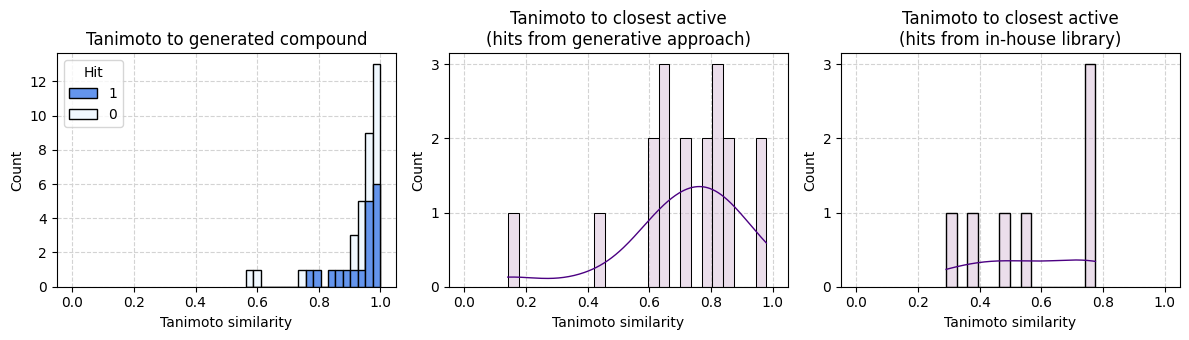

In [20]:
import seaborn as sns
from matplotlib.ticker import LogLocator

import matplotlib.pyplot as plt

# Convert mm to inches (matplotlib uses inches)
width_mm = 120
width_inches = width_mm / 25.4

# Create the figure with the specified width
fig, [ax1, ax2, ax3] = plt.subplots(1, 3, figsize=(12, 3.5))

sns.histplot(
    data=global_results,
    x="tanimotos",
    hue="Hit",
    binwidth=0.025,
    palette=["cornflowerblue", "aliceblue"],
    alpha=1,
    hue_order=[1, 0],
    zorder=2,
    ax=ax1,
)

sns.histplot(max_sim, kde=True, zorder=2, ax=ax2, binwidth=0.035, color="thistle")
kde_line = ax2.lines[0]
kde_line.set_color("indigo")
kde_line.set_linewidth(1)

sns.histplot(max_sim_irb, kde=True, zorder=2, ax=ax3, binwidth=0.035, color="thistle")
kde_line = ax3.lines[0]
kde_line.set_color("indigo")
kde_line.set_linewidth(1)

ax1.grid(axis="both", ls="--", c="lightgrey", zorder=0)
ax2.grid(axis="both", ls="--", c="lightgrey", zorder=0)
ax3.grid(axis="both", ls="--", c="lightgrey", zorder=0)

ax1.set_xlabel("Tanimoto similarity")
ax2.set_xlabel("Tanimoto similarity")
ax3.set_xlabel("Tanimoto similarity")

for ax in [ax2, ax3, ax1]:
    ax.set_xlim(-0.05, 1.05)

ax2.set_yticks(np.arange(0, 3.1, 1))
ax3.set_yticks(np.arange(0, 3.1, 1))

ax1.set_title("Tanimoto to generated compound")
ax2.set_title("Tanimoto to closest active\n(hits from generative approach)")
ax3.set_title("Tanimoto to closest active\n(hits from in-house library)")

# Adjust the spacing between subplots
plt.tight_layout()

plt.show()